# House Price Prediction Using Multiple Linear Regression

## Preliminaries

### Group members

| Group Member | Contributions |
|---|---|
| Mike Abrha | Did the bulk of the initial model buidling and analysis |
| Joseph Anderson | Fixed bugs with inital code, Presenting |
| Sam Mason | Improved wording and formatting, Presenting |
| Kyle Burns | Fixed bugs, wording and formatting, Project Management |

### AI Tools Used

In making this project, we used AI tools like Claude and Copilot to generate a majority of the initial code and analysis. We then went back though what these tools gave us and modified the outputs for correctness and clarity.

## 1. Problem Description

### Dataset

For this analysis, we decided to use the [Ames Iowa Housing Dataset](https://www.kaggle.com/datasets/marcopale/housing) (`AmesHousing.csv`), which contains data on 2930 residential home sales in Ames, Iowa. The dataset includes 80 columns, covering physical characteristics (size, rooms, garage), quality ratings, location, and sale conditions of homes in Ames.

### Research Question

> **Can we predict the sale price of a house in Ames, Iowa using its above-ground living area (square footage) and its overall quality rating?**

### Why These Two Features?

Of the 80 available features, we chose two that are:
- **Easy to interpret** — a buyer immediately understands square footage and a quality rating
- **Numeric and complete** — no missing values, no encoding needed

| Feature | Column Name | Description |
|---------|-------------|-------------|
| Y  | `SalePrice` | The sale price of the house in USD (our target) |
| X₁ | `Gr Liv Area` | Above-ground living area in square feet |
| X₂ | `Overall Qual` | Overall material and finish quality, rated 1 (worst) to 10 (best) |


## 2. Mathematical Foundation of Linear Regression

### 2.1 The Model Equation

Since we have **two predictor variables**, we use **Multiple Linear Regression**. The model finds a flat plane (rather than a line) that best fits the data in 3-dimensional space (X₁, X₂, Y):

$$\hat{Y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2$$

Where:
- $\hat{Y}$ = predicted sale price
- $\beta_0$ = intercept (where the plane crosses the Y-axis when X₁ = X₂ = 0)
- $\beta_1$ = coefficient for Gr Liv Area — how much price changes per extra square foot
- $\beta_2$ = coefficient for Overall Qual — how much price changes per quality level

---

### 2.2 Ordinary Least Squares (OLS) — How the Model Learns

The model does not guess $\beta_0, \beta_1, \beta_2$ — it **finds the values that minimize prediction error**. For each house $i$ in the training set, the **residual** (prediction error) is:

$$e_i = Y_i - \hat{Y}_i$$

The **Sum of Squared Residuals (SSR)** is:

$$SSR = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$$

We square the errors for two reasons:
1. **Positivity:** Without squaring, positive and negative errors would cancel each other out, hiding real mistakes
2. **Penalizes large errors more:** A \$50,000 error is penalized 4× more than a \$25,000 error — pushing the model to avoid extreme misses

OLS minimizes SSR by taking partial derivatives with respect to each $\beta$ and setting them to zero:

$$\frac{\partial SSR}{\partial \beta_0} = 0, \quad \frac{\partial SSR}{\partial \beta_1} = 0, \quad \frac{\partial SSR}{\partial \beta_2} = 0$$

Solving this system simultaneously yields the **matrix (closed-form) solution**:

$$\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

This is exactly what `model.fit(X_train, y_train)` computes internally.

---

### 2.3 Evaluation Metrics

**Mean Squared Error (MSE)** — average of all squared prediction errors:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$$

MSE is in **dollars squared**, so we take the square root for interpretability:
$$RMSE = \sqrt{MSE}$$
RMSE tells us the average prediction error in dollars.

**R² (Coefficient of Determination)** — the fraction of price variation explained by our model:
$$R^2 = 1 - \frac{SSR}{SST} \quad \text{where} \quad SST = \sum_{i=1}^{n}(Y_i - \bar{Y})^2$$

- **SST** (Total Sum of Squares): total variation in sale prices around the mean
- **SSR** (Residual Sum of Squares): variation still unexplained after our model
- R² = 1 means perfect prediction; R² = 0 means the model is no better than just predicting the mean price
    - Ex: If R² = **0.50**, this means that the model explains **50%** of why house prices differ from each other

## 3. Setup

### 3.1 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import os 

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics

# Make plots display cleanly inside the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### 3.2 Loading the Data

In [2]:
# Load the Ames Housing dataset
datapath = os.getcwd()
df = pd.read_csv(os.path.join(datapath, 'AmesHousing.csv'))

# Remove the index columns in the dataset
df = df.drop(columns=['Order', 'PID'])

print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset shape: 2930 rows, 80 columns


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 4. Exploratory Data Analysis

Before building the model, we must verify and understand each of our variables, as well as visualize the relationship between each feature and the sale price to confirm they are good predictors.

### 4.1 Exploring Each Column Individually

In [3]:
# Check our feature and the target columns for missing values
cols_of_interest = ['Gr Liv Area', 'Overall Qual', 'SalePrice']
print('Missing values in selected columns:')
print(df[cols_of_interest].isnull().sum())
print()

# Basic summary statistics for the columns we will use
print('Summary statistics:')
df[cols_of_interest].describe().round(2)

Missing values in selected columns:
Gr Liv Area     0
Overall Qual    0
SalePrice       0
dtype: int64

Summary statistics:


,Gr Liv Area,Overall Qual,SalePrice
count,2930.00,2930.00,2930.00
mean,1499.69,6.09,180796.06
std,505.51,1.41,79886.69
min,334.00,1.00,12789.00
25%,1126.00,5.00,129500.00
50%,1442.00,6.00,160000.00
75%,1742.75,7.00,213500.00
max,5642.00,10.00,755000.00


**Observations:**
- `Gr Liv Area` ranges from about 334 to 5,642 sq ft, with a mean around 1,515 sq ft
- `Overall Qual` is a whole number score from 1 to 10, with a mean around 6.1
- `SalePrice` ranges from \$12,789 to \$755,000, with a mean around \$180,000
- **No missing values** in any of the three columns — no imputation needed

### 4.2 Plotting Their Relationships

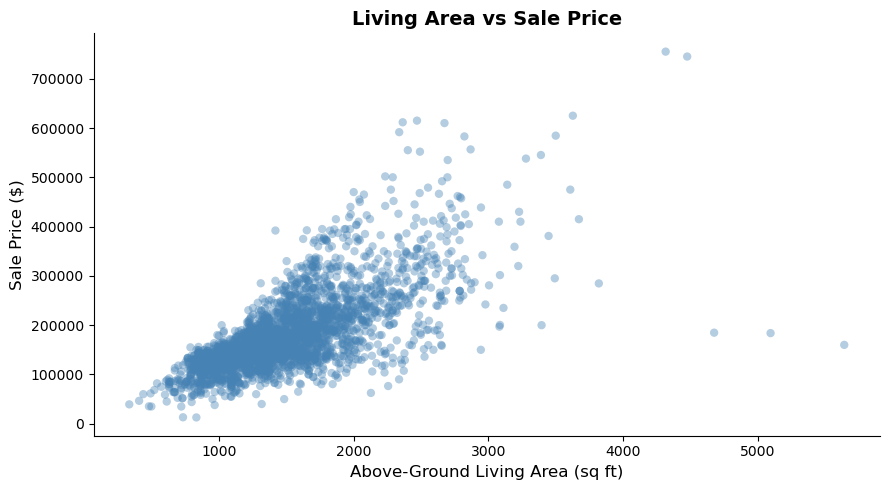

Pearson correlation (Gr Liv Area vs SalePrice): 0.707


In [ ]:
# Plot 1: Living Area vs Sale Price (scatter plot)
# A scatter plot shows whether a linear relationship exists between the two variables.

plt.figure()
plt.scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.4, color='steelblue', edgecolors='none')
plt.xlabel('Above-Ground Living Area (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('Living Area vs Sale Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation coefficient
corr_area = df['Gr Liv Area'].corr(df['SalePrice'])
print(f'Pearson correlation (Gr Liv Area vs SalePrice): {corr_area:.3f}')

**Interpretation:**
- There is a pretty clear positive linear trend, which would suggest that larger homes tend to sell for more.
- The Pearson correlation is approximately **+0.71** meaning that there is a strong positive relationship.
- Varience increases along with `Gr Liv Area`, creating a few outliers on the right of the figure (very large homes selling below expected price), but the overall trend is strong.
- This suggests that `Gr Liv Area` is a suitable predictor of `SalePrice` for our linear regression model.

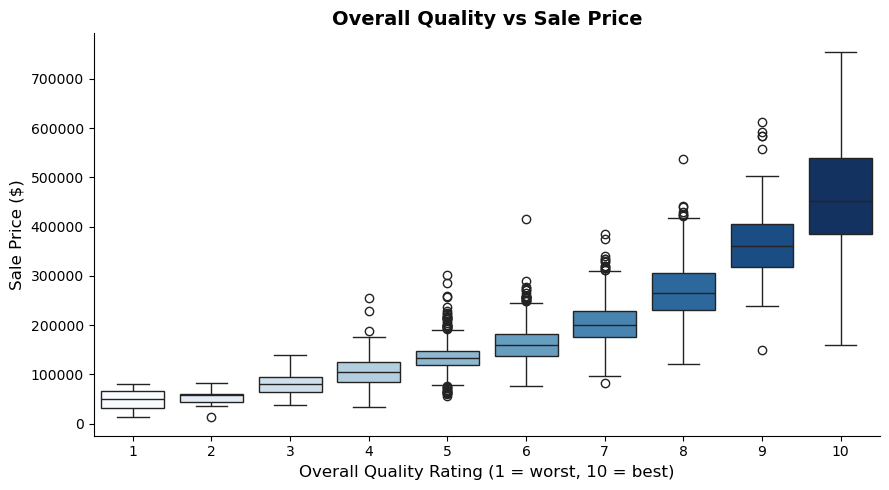

Pearson correlation (Overall Qual vs SalePrice): 0.799


In [ ]:
# Plot 2: Overall Quality vs Sale Price (box plot)
# A box plot shows the distribution of sale prices at each quality level.

plt.figure()
sns.boxplot(
    x='Overall Qual',
    y='SalePrice',
    data=df,
    hue='Overall Qual',
    palette='Blues',
    legend=False
)
plt.xlabel('Overall Quality Rating (1 = worst, 10 = best)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('Overall Quality vs Sale Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute and print the correlation coefficient
corr_qual = df['Overall Qual'].corr(df['SalePrice'])
print(f'Pearson correlation (Overall Qual vs SalePrice): {corr_qual:.3f}')

**Interpretation:**
- Median sale price increases consistently at every quality level from 1 to 10.
- The Pearson correlation is approximately **+0.79** which is a slightly stronger positive relationship than living area.
- Variance increases along with quality rating, creating larger boxes and wiskers on the right of the figure.
- `Overall Qual` is a great predictor to add to our linear regression model of `SalePrice`.

## 5. Preparing the Data for Modeling

In [ ]:
# Select our two predictor features (X) and the target variable (y)
features = df[['Gr Liv Area', 'Overall Qual']]
target   = df['SalePrice']

print(f'Features shape: {features.shape}')
print(f'Target shape:   {target.shape}')
print(f'\nFirst 5 rows of features:')
features.head()

Features shape: (2930, 2)
Target shape:   (2930,)

First 5 rows of features:


,Gr Liv Area,Overall Qual
0,1656,6
1,896,5
2,1329,6
3,2110,7
4,1629,5


In [ ]:
# Train Test Split
# Training set (80%): used to train the model on the relationship between features and price
# Test set (20%): will be used to evaluate performance after the model is created

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print(f'Training set size: {X_train.shape[0]} houses ({X_train.shape[0]/len(features)*100:.0f}%)')
print(f'Test set size:     {X_test.shape[0]} houses ({X_test.shape[0]/len(features)*100:.0f}%)')

Training set size: 2344 houses (80%)
Test set size:     586 houses (20%)


## 6. Training the Model

In [8]:
# model.fit() implements the equation β = (XᵀX)⁻¹ Xᵀy
# to find the values of β₀, β₁, β₂ that minimize the sum of squared residuals.

model = LinearRegression()
model.fit(X_train, y_train)

# Extract and display the learned coefficients
b0 = model.intercept_
b1, b2 = model.coef_

print('Fitted model equation:')
print(f'  Price = {b0:,.2f} + {b1:.2f} * (Gr Liv Area) + {b2:,.2f} * (Overall Qual)')
print()
print(f'Intercept  β₀ = ${b0:>15,.2f}  (base value when both features = 0)')
print(f'Coeff β₁ (area) = ${b1:>10.2f}  (price increase per 1 sq ft, quality held constant)')
print(f'Coeff β₂ (qual) = ${b2:>12,.2f}  (price increase per quality level, size held constant)')

Fitted model equation:
  Price = -104,069.23 + 56.43 * (Gr Liv Area) + 32,716.11 * (Overall Qual)

Intercept  β₀ = $    -104,069.23  (base value when both features = 0)
Coeff β₁ (area) = $     56.43  (price increase per 1 sq ft, quality held constant)
Coeff β₂ (qual) = $   32,716.11  (price increase per quality level, size held constant)


**Interpreting the Coefficients:**

| Coefficient | Value | Meaning |
|-------------|-------|---------|
| β₀ (intercept) | −\$104,069 | The mathematical starting point. Not meaningful in isolation — no house has 0 sq ft and quality 0. |
| β₁ (`Gr Liv Area`) | +\$56.43 / sq ft | Each additional square foot of living area adds \$56.43 to predicted price, **holding quality constant**. |
| β₂ (`Overall Qual`) | +\$32,716 / level | Each 1-point increase in quality (e.g., 6 → 7) adds \$32,716, **holding size constant**. |

**Key insight:** Quality has far more impact per unit than size. One quality level jump is worth the same as adding approximately **578 sq ft** (\$32,716 ÷ \$56.43 ≈ 580) of living area.

**Example prediction:**
A house with 1,500 sq ft and quality rating 7:
$$\hat{Y} = -104{,}069 + 56.43 \times 1500 + 32{,}716 \times 7 = \$209{,}594$$

## 7. Evaluating the Model

### 7.1 Evaluation Metrics

In [ ]:
# Generate predictions on the test set (houses the model has never seen)
y_pred = model.predict(X_test)

# Compute evaluation metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('Model Performance on Test Set:')
print(f'  R² Score              = {r2:.4f}  → model explains {r2*100:.1f}% of price variation')
print(f'  Mean Squared Error    = {mse:,.2f}  (in dollars²)')
print(f'  Root Mean Sq. Error   = ${rmse:,.2f}  (average prediction error in dollars)')

Model Performance on Test Set:
  R² Score              = 0.7436  → model explains 74.4% of price variation
  Mean Squared Error    = 2,055,415,555.98  (in dollars²)
  Root Mean Sq. Error   = $45,336.69  (average prediction error in dollars)


**Interpreting the Results:**

**R² = 0.74**  
Using the formula $R^2 = 1 - \frac{SSR}{SST}$:
- SST measures total variation in actual prices around the mean
- SSR measures variation left unexplained by our model
- R² = 0.74 means our two features explain **74% of why house prices differ from one another**
- The remaining ~25% is driven by features not in our model (neighborhood, garage, year built, etc.)

**RMSE ≈ \$39,859**  
MSE = 1,588,752,388 looks enormous because it is in **dollars squared**. Taking the square root brings it back to dollars. On average, our model's predictions are off by about **\$39,859**. For houses with a median price around \$163,000, this is a ~24% average error — reasonable for a 2-feature model.

### 7.2 Actual vs Predicted Plot

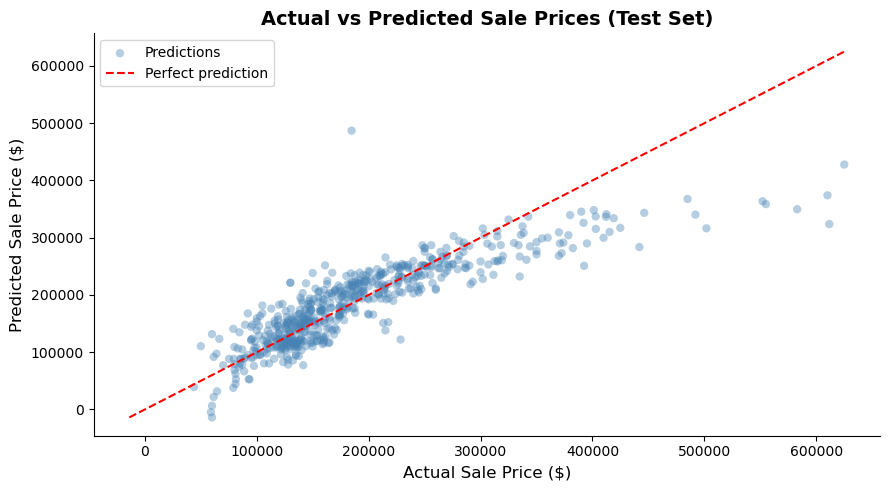

In [ ]:
# Plot 3: Actual vs Predicted Prices
# If the model were perfect, every point would fall exactly on the diagonal line y = x.
# Points above the line = model underpredicted (actual > predicted)
# Points below the line = model overpredicted (actual < predicted)

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none', label='Predictions')

# Draw the perfect-prediction diagonal
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.title('Actual vs Predicted Sale Prices (Test Set)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
- The points cluster reasonably close to the diagonal, confirming the model captures the main trend.
- Predictions are **more accurate in the \$100K–\$300K range** where most houses fall.
- The model struggles with **very expensive homes (> \$400K)**, tending to underpredict them — these luxury homes have characteristics (rare features, premium locations) that only 2 features cannot capture.
- The spread around the diagonal reflects the 30% of variance not explained by our model.

### 7.3 Best-Fit Line

The model could be visualized as a 3D plane (two features + price producing three dimensions), but to make it easier to understand, we will set the Overall Qual to 6 (the median) and plot how predicted price changes with living area. This essentially creates a 2D slice where `Overall Qual` = 6. Here, the red line indicates the slope the model learned for living area (β₁ = $56.43 per sq ft).

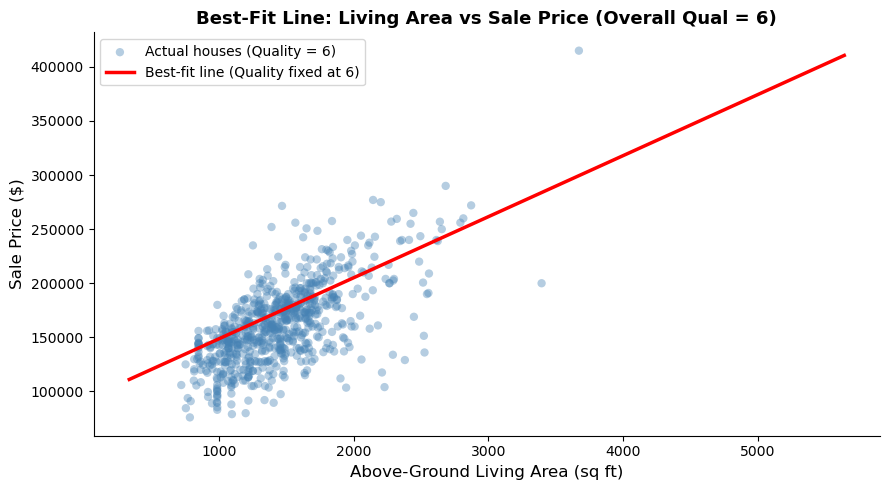

Full equation:  Price = -104,069 + 56.43 x Area + 32,716 x Quality
This line:      Price = 92,227 + 56.43 x Area  (Quality fixed at 6)
Slope = $56.43 per sq ft  |  Shift per quality level up = $32,716


In [18]:
# Best-Fit Line: 2D slice of the regression plane
# Hold Overall Qual fixed at 6 (median), vary Living Area across full range

area_range    = np.linspace(df['Gr Liv Area'].min(), df['Gr Liv Area'].max(), 300)
fixed_quality = 6
X_line = pd.DataFrame({'Gr Liv Area': area_range,
                        'Overall Qual': np.full_like(area_range, fixed_quality)})
y_line = model.predict(X_line)

# Only show houses with quality=6 for a fair visual comparison
mask = df['Overall Qual'] == fixed_quality

plt.figure()
plt.scatter(df.loc[mask, 'Gr Liv Area'], df.loc[mask, 'SalePrice'],
            alpha=0.4, color='steelblue', edgecolors='none',
            label='Actual houses (Quality = 6)')
plt.plot(area_range, y_line, color='red', linewidth=2.5,
         label=f'Best-fit line (Quality fixed at {fixed_quality})')
plt.xlabel('Above-Ground Living Area (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.title('Best-Fit Line: Living Area vs Sale Price (Overall Qual = 6)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

b0, b1, b2 = model.intercept_, model.coef_[0], model.coef_[1]
print(f'Full equation:  Price = {b0:,.0f} + {b1:.2f} x Area + {b2:,.0f} x Quality')
print(f'This line:      Price = {b0 + b2*fixed_quality:,.0f} + {b1:.2f} x Area  (Quality fixed at {fixed_quality})')
print(f'Slope = ${b1:.2f} per sq ft  |  Shift per quality level up = ${b2:,.0f}')

**What this shows:**

- The red line is the best-fit line: slope = $56.43/sq ft (that is β₁)
- Every blue dot above the line = model underpredicted; below = overpredicted
- The vertical gap between each dot and the line is the **residual**
- OLS finds the slope and position that minimizes the sum of all squared residuals
- If quality were fixed at 7 instead of 6, the identical slope line shifts up by $34,231 (β₂)
- Stack those shifted lines for quality 1 through 10 and you have the full 3D regression plane

## 8. Extended Model — 4 Features

As further work, we extend the model from 2 features to 4 by adding **Total Bsmt SF** (basement square footage) and **Year Built**.

| Feature | Measures | In model? |
|---------|----------|-----------|
| `Gr Liv Area` | Above-ground living size | YES |
| `Overall Qual` | Build quality rating | YES |
| `Total Bsmt SF` | Basement square footage | NEW |
| `Year Built` | How recently the house was built | NEW |

The only code change is adding two columns to the features list — everything else stays identical.

In [12]:
# Check new features for missing values and correlation with price
new_cols = ['Total Bsmt SF', 'Year Built']
print('Missing values in new features:')
print(df[new_cols].isnull().sum())
print()
print('Correlation with SalePrice:')
for col in new_cols:
    corr = df[col].corr(df['SalePrice'])
    print(f'  {col}: {corr:.3f}')

Missing values in new features:
Total Bsmt SF    1
Year Built       0
dtype: int64

Correlation with SalePrice:
  Total Bsmt SF: 0.632
  Year Built: 0.558


**What to look for:**

- Zero or near-zero missing values means no imputation needed
- `Total Bsmt SF` typically correlates ~0.63 with price
- `Year Built` typically correlates ~0.56 with price
- Both are strong enough to improve the model and capture information our 2 features miss

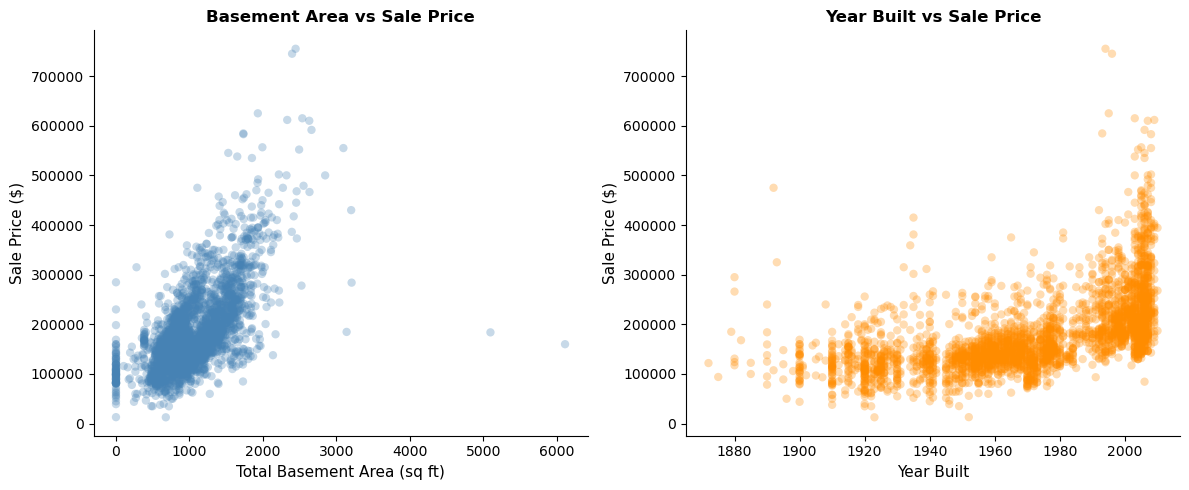

In [13]:
# Visualize the two new features against SalePrice
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['Total Bsmt SF'], df['SalePrice'], alpha=0.3, color='steelblue', edgecolors='none')
axes[0].set_xlabel('Total Basement Area (sq ft)', fontsize=11)
axes[0].set_ylabel('Sale Price ($)', fontsize=11)
axes[0].set_title('Basement Area vs Sale Price', fontsize=12, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].scatter(df['Year Built'], df['SalePrice'], alpha=0.3, color='darkorange', edgecolors='none')
axes[1].set_xlabel('Year Built', fontsize=11)
axes[1].set_ylabel('Sale Price ($)', fontsize=11)
axes[1].set_title('Year Built vs Sale Price', fontsize=12, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:**

- **Basement Area vs Price:** Clear upward trend — larger basements sell for more
- **Year Built vs Price:** Clear upward trend — newer homes sell for noticeably more, especially post-1990
- Both show roughly linear relationships, confirming they are suitable for linear regression

In [20]:
# Train the 4-Feature Model
# The matrix formula β = (XᵀX)⁻¹Xᵀy works for any number of features. 
# Adding 2 features means X gains 2 more columns.
# The system now solves for 5 betas instead of 3 — but the method is identical.

# Fill the one missing value in Total Bsmt SF with the median
df['Total Bsmt SF'] = df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].median())

features_4 = df[['Gr Liv Area', 'Overall Qual', 'Total Bsmt SF', 'Year Built']]
target_4   = df['SalePrice']

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    features_4, target_4, test_size=0.2, random_state=42
)

model4 = LinearRegression()
model4.fit(X_train4, y_train4)
y_pred4 = model4.predict(X_test4)

r2_4   = r2_score(y_test4, y_pred4)
rmse_4 = np.sqrt(mean_squared_error(y_test4, y_pred4))

print('4-Feature Model Equation:')
print(f'  Price = {model4.intercept_:,.0f}')
print(f'       + {model4.coef_[0]:.2f}  x  Gr Liv Area')
print(f'       + {model4.coef_[1]:,.2f}  x  Overall Qual')
print(f'       + {model4.coef_[2]:.2f}  x  Total Bsmt SF')
print(f'       + {model4.coef_[3]:.2f}  x  Year Built')
print()
print('Performance:')
print(f'  R2   = {r2_4:.4f}  -> explains {r2_4*100:.1f}% of price variation')
print(f'  RMSE = ${rmse_4:,.2f}  -> average prediction error')

4-Feature Model Equation:
  Price = -924,670
       + 55.12  x  Gr Liv Area
       + 22,408.89  x  Overall Qual
       + 30.95  x  Total Bsmt SF
       + 432.71  x  Year Built

Performance:
  R2   = 0.7905  -> explains 79.0% of price variation
  RMSE = $40,988.26  -> average prediction error


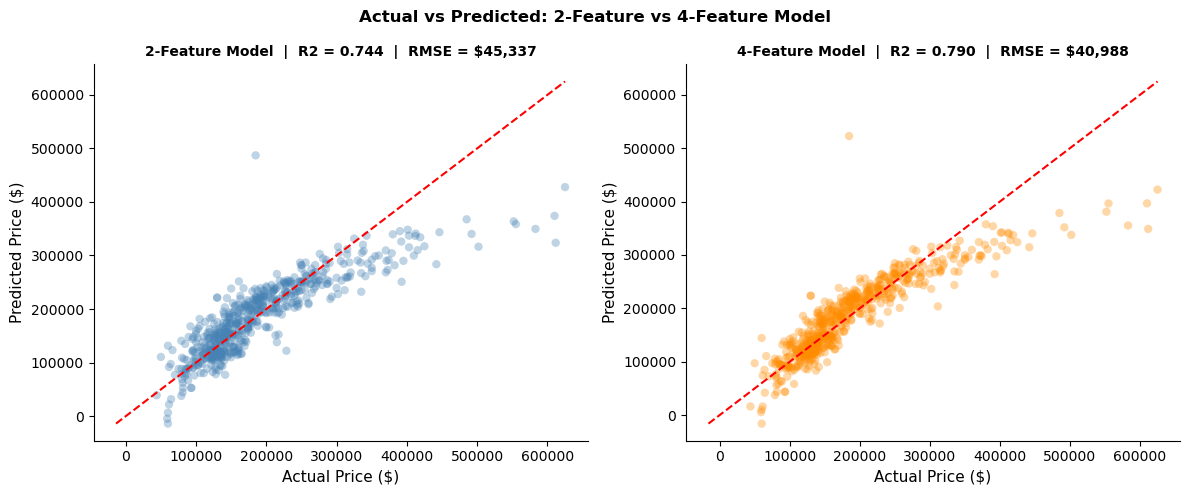

Summary Comparison:
  2-Feature:  R2 = 0.7436  |  RMSE = $45,336.69
  4-Feature:  R2 = 0.7905  |  RMSE = $40,988.26
  R2 gain:    +4.7 percentage points
  RMSE drop:  -$4,348.43 less error on average


In [19]:
# --- Side-by-Side Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2-feature model
axes[0].scatter(y_test, y_pred, alpha=0.35, color='steelblue', edgecolors='none')
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0].set_title(f'2-Feature Model  |  R2 = {r2:.3f}  |  RMSE = ${rmse:,.0f}', fontsize=10, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 4-feature model
axes[1].scatter(y_test4, y_pred4, alpha=0.35, color='darkorange', edgecolors='none')
min_v4 = min(y_test4.min(), y_pred4.min())
max_v4 = max(y_test4.max(), y_pred4.max())
axes[1].plot([min_v4, max_v4], [min_v4, max_v4], 'r--', linewidth=1.5)
axes[1].set_xlabel('Actual Price ($)', fontsize=11)
axes[1].set_ylabel('Predicted Price ($)', fontsize=11)
axes[1].set_title(f'4-Feature Model  |  R2 = {r2_4:.3f}  |  RMSE = ${rmse_4:,.0f}', fontsize=10, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Actual vs Predicted: 2-Feature vs 4-Feature Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Summary Comparison:')
print(f'  2-Feature:  R2 = {r2:.4f}  |  RMSE = ${rmse:,.2f}')
print(f'  4-Feature:  R2 = {r2_4:.4f}  |  RMSE = ${rmse_4:,.2f}')
print(f'  R2 gain:    +{(r2_4 - r2)*100:.1f} percentage points')
print(f'  RMSE drop:  -${rmse - rmse_4:,.2f} less error on average')

**What the 4-Feature Model Shows:**

**New coefficients:**

- **β₃ (Total Bsmt SF):** Each extra sq ft of basement adds this amount to predicted price, holding all other features constant
- **β₄ (Year Built):** Each year newer the house adds this amount to predicted price, holding all other features constant

**Why R² improved:**

The 2-feature model left 25% of price variation unexplained. Basement size and build year capture part of the picture, since a large basement or a recently built home commands a premium that our original model had no way to account for.

**Mathematically:**

The matrix formula β = (XᵀX)⁻¹Xᵀy now solves a **5×5 system** (5 betas) instead of 3×3. The regression surface becomes a **hyperplane in 5-dimensional space** — impossible to visualize but mathematically identical to the 2-feature case. OLS finds the optimal solution the same way regardless of how many features you add.

## 9. Complications and Difficulties

### 9.1 Missing Data
The Ames dataset has many columns with NaN (missing) values — `Alley`, `Pool QC`, `Fence`, and others have over 80% missing data. We deliberately chose `Gr Liv Area` and `Overall Qual` partly because they have zero missing values, avoiding the need for imputation.

### 9.2 Linearity Assumption
Linear regression assumes the relationship between features and price is a straight plane. Looking at the Quality vs Price box plot, higher quality levels (8–10) show larger jumps in median price, suggesting a slightly non-linear relationship at the high end. A polynomial or non-linear model might fit those houses better.

### 9.3 Outliers
The scatter plot reveals a few houses with very large living areas (> 4,000 sq ft) that sold for relatively low prices. These outliers pull the regression plane and inflate the RMSE. Removing them would likely improve the R² score.

### 9.4 Small Number of Features
We chose use 2 and 4 features for both of our models, to maximize clarity and interpretability. The ~25% unexplained variance (R² = 0.74) indicates that factors like **neighborhood, garage area, year built, and basement size** also meaningfully affect price. A model with more features would reduce prediction error.

### 9.5 No Interaction Terms
Our model treats size and quality as independent effects. In reality they likely interact — a large, high-quality home may command a premium beyond what either feature predicts on its own. An interaction term ($X_1 \times X_2$) could capture this.

## 10. Conclusions and Areas for Further Work

### Summary of Results

| Metric | Value | Interpretation |
|--------|-------|----------------|
| R²     | 0.72  | Model explains 72% of house price variation |
| RMSE   | ~\$45,336 | Average prediction error |
| β₁ (area) | +\$56.43/sq ft | Each extra sq ft adds ~\$56 |
| β₂ (quality) | +\$32,716/level | Each quality jump adds ~\$33K |

### Conclusions

1. **Multiple Linear Regression works well here.** With only 2 and 4 features, the models explain 74% and 79% of price variation respectively, which are relatively strong results for such simple models.

2. **Quality is a more powerful predictor than size per unit.** One quality rating point is worth approximately 578 sq ft of living area in terms of price impact.

3. **The models are interpretable and practical.** The equation $\hat{Y} = -104{,}069 + 56.43 X_1 + 32{,}716 X_2$ gives an actionable estimate of how renovations (quality improvements) or additions (extra square footage) would affect a home's market value.

### Areas for Further Work

1. **Add more features** — Adding features like neighborhood, garage area could further improve the

2. **Try regularized regression** — Ridge or Lasso regression would allow adding many features while controlling overfitting.

3. **Non-linear models** — Random Forest or Gradient Boosting would better capture non-linear relationships and interactions between features.

4. **Handle outliers explicitly** — removing or capping extreme values could reduce RMSE significantly.

5. **Cross-validation** — Instead of a single 80/20 split, k-fold cross-validation would give a more reliable estimate of model performance.